In [7]:
OPENAI_KEY = "..."

In [9]:
import numpy as np
import pandas as pd
import openai
openai_client = openai.Client(api_key=OPENAI_KEY)

In [20]:
df = pd.read_csv("Dataset/train_joined.csv", header=None, names=["id", "text", "category", "date", "label"])
df = df[df["label"] == 1]

          id                                               text      category  \
0       2619  Ex-CIA head says Trump remarks on Russia inter...  politicsNews   
2        876  Federal Reserve governor Powell's policy views...  politicsNews   
5      18522  EU's Tusk appealed to Rajoy to avoid escalatio...     worldnews   
7       7628  Clinton says 'there is no case here' in FBI em...  politicsNews   
10      8071  Trump opposes plan for U.S. to cede internet o...  politicsNews   
...      ...                                                ...           ...   
29992   1561  U.S. Senate panel backs Huntsman to be Trump's...  politicsNews   
29995   6880  U.S. aerospace industry urges Trump to help Ex...  politicsNews   
29996  17818  Highlights: Hong Kong leader Carrie Lam delive...     worldnews   
29998  15805  Syrian army takes full control of Deir al-Zor ...     worldnews   
29999   8143  U.S., Israel sign $38 billion military aid pac...  politicsNews   

                      date 

In [21]:
all_embeddings = []
for start in range(0, len(df), 100):
    end = min(start + 100, len(df))
    block = df.iloc[start:end-1]
    result = openai_client.embeddings.create(
        input=block["text"].tolist(),
        model="text-embedding-3-large"
    )
    embeddings = [emb.embedding for emb in result.data]
    all_embeddings.extend(embeddings)
    print(f"Processed {start} to {end} out of {len(df)}")

df["embedding"] = pd.Series(all_embeddings, dtype=object)
df.to_csv("Dataset/train_joined_emb.csv", index=False)

Processed 0 to 100 out of 14522
Processed 100 to 200 out of 14522
Processed 200 to 300 out of 14522
Processed 300 to 400 out of 14522
Processed 400 to 500 out of 14522
Processed 500 to 600 out of 14522
Processed 600 to 700 out of 14522
Processed 700 to 800 out of 14522
Processed 800 to 900 out of 14522
Processed 900 to 1000 out of 14522
Processed 1000 to 1100 out of 14522
Processed 1100 to 1200 out of 14522
Processed 1200 to 1300 out of 14522
Processed 1300 to 1400 out of 14522
Processed 1400 to 1500 out of 14522
Processed 1500 to 1600 out of 14522
Processed 1600 to 1700 out of 14522
Processed 1700 to 1800 out of 14522
Processed 1800 to 1900 out of 14522
Processed 1900 to 2000 out of 14522
Processed 2000 to 2100 out of 14522
Processed 2100 to 2200 out of 14522
Processed 2200 to 2300 out of 14522
Processed 2300 to 2400 out of 14522
Processed 2400 to 2500 out of 14522
Processed 2500 to 2600 out of 14522
Processed 2600 to 2700 out of 14522
Processed 2700 to 2800 out of 14522
Processed 280

In [24]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(all_embeddings)

In [30]:
import umap.umap_ as umap
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X_pca)

C:\Users\mnevv\PycharmProjects\FakeNews_detection_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\mnevv\PycharmProjects\FakeNews_detection_project\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\mnevv\PycharmProjects\FakeNews_detection_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [40]:
import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=100, metric='euclidean')
labels = clusterer.fit_predict(X_pca)

C:\Users\mnevv\PycharmProjects\FakeNews_detection_project\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\mnevv\PycharmProjects\FakeNews_detection_project\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [41]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
sil = silhouette_score(X_pca, labels)
db = davies_bouldin_score(X_pca, labels)
print(f"Silhouette: {sil:.3f}, Davies–Bouldin: {db:.3f}")

Silhouette: -0.008, Davies–Bouldin: 3.497


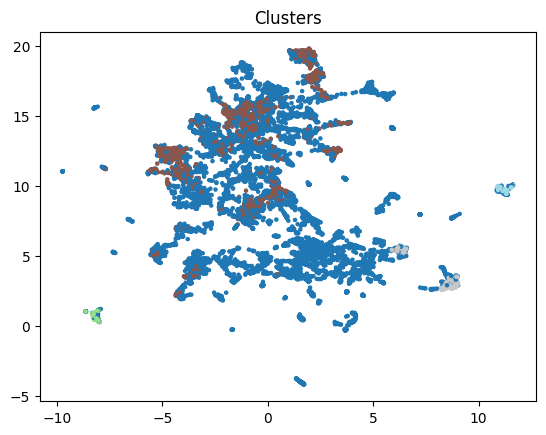

In [42]:
import matplotlib.pyplot as plt
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap='tab20', s=5)
plt.title("Clusters")
plt.show()